# Testing ChEMBL Python client

In [1]:
from chembl_webresource_client.settings import Settings
Settings.Instance().TIMEOUT = 10

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [2]:
from chembl_webresource_client.new_client import new_client

available_resources = [resource for resource in dir(new_client) if not resource.startswith('_')]
print(available_resources)

['activity', 'activity_supplementary_data_by_activity', 'assay', 'assay_class', 'atc_class', 'binding_site', 'biotherapeutic', 'cell_line', 'chembl_id_lookup', 'chembl_release', 'compound_record', 'compound_structural_alert', 'description', 'document', 'document_similarity', 'drug', 'drug_indication', 'drug_warning', 'go_slim', 'image', 'mechanism', 'metabolism', 'molecule', 'molecule_form', 'official', 'organism', 'protein_classification', 'similarity', 'source', 'substructure', 'target', 'target_component', 'target_relation', 'tissue', 'xref_source']


In [7]:
from IPython.display import SVG

In [3]:
molecule = new_client.molecule
mols = molecule.filter(pref_name__iexact='aspirin')
mols

[{'atc_classifications': ['B01AC06', 'N02BA01', 'N02BA51', 'A01AD05', 'N02BA71'], 'availability_type': 2, 'biotherapeutic': None, 'black_box_warning': 0, 'chemical_probe': 0, 'chirality': 2, 'cross_references': [{'xref_id': 'aspirin', 'xref_name': 'aspirin', 'xref_src': 'DailyMed'}], 'dosed_ingredient': True, 'first_approval': 1950, 'first_in_class': 0, 'helm_notation': None, 'inorganic_flag': 0, 'max_phase': '4.0', 'molecule_chembl_id': 'CHEMBL25', 'molecule_hierarchy': {'active_chembl_id': 'CHEMBL25', 'molecule_chembl_id': 'CHEMBL25', 'parent_chembl_id': 'CHEMBL25'}, 'molecule_properties': {'alogp': '1.31', 'aromatic_rings': 1, 'full_molformula': 'C9H8O4', 'full_mwt': '180.16', 'hba': 3, 'hbd': 1, 'heavy_atoms': 13, 'mw_freebase': '180.16', 'np_likeness_score': '0.12', 'num_ro5_violations': 0, 'psa': '63.60', 'qed_weighted': '0.55', 'ro3_pass': 'N', 'rtb': 2}, 'molecule_structures': {'canonical_smiles': 'CC(=O)Oc1ccccc1C(=O)O', 'molfile': '\n     RDKit          2D\n\n 13 13  0  0  0 

In [4]:
mols2 = molecule.filter(molecule_synonyms__molecule_synonym__iexact='viagra').only('molecule_chembl_id')
mols2

[{'molecule_chembl_id': 'CHEMBL1737'}]

In [5]:
m1 = molecule.filter(chembl_id='CHEMBL192').only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])
m1

[{'molecule_chembl_id': 'CHEMBL192', 'molecule_structures': {'canonical_smiles': 'CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12', 'molfile': '\n     RDKit          2D\n\n 33 36  0  0  0  0  0  0  0  0999 V2000\n    2.1000   -0.0042    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.1000    0.7000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5375   -0.0042    0.0000 S   0  0  0  0  0  0  0  0  0  0  0  0\n    1.4917   -0.3667    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8792   -0.0042    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.8042    0.9083    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    1.4917    1.0625    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8792    0.6833    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    3.2042    0.3458    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    2.8042   -0.2417    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.2875   -0.3750    0.0000 C   0  0  0  0  0  0  0  0  0  

In [6]:
mols3 = molecule.filter(molecule_chembl_id__in=['CHEMBL25', 'CHEMBL192', 'CHEMBL27']).only(['molecule_chembl_id', 'pref_name'])
mols3

[{'molecule_chembl_id': 'CHEMBL25', 'pref_name': 'ASPIRIN'}, {'molecule_chembl_id': 'CHEMBL27', 'pref_name': 'PROPRANOLOL'}, {'molecule_chembl_id': 'CHEMBL192', 'pref_name': 'SILDENAFIL'}]

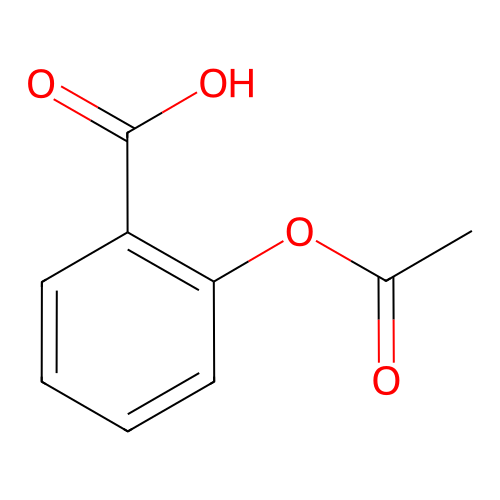

In [8]:
image = new_client.image
image.set_format('svg')
SVG(image.get('CHEMBL25'))

In [9]:
mol = molecule.filter(molecule_structures__standard_inchi_key='BSYNRYMUTXBXSQ-UHFFFAOYSA-N').only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])
mol

[{'molecule_chembl_id': 'CHEMBL25', 'molecule_structures': {'canonical_smiles': 'CC(=O)Oc1ccccc1C(=O)O', 'molfile': '\n     RDKit          2D\n\n 13 13  0  0  0  0  0  0  0  0999 V2000\n   19.8052   -4.2758    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   19.8040   -5.0953    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   20.5121   -5.5043    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   21.2217   -5.0948    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   21.2189   -4.2722    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   20.5103   -3.8669    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   20.5078   -3.0497    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   21.2143   -2.6390    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   19.7989   -2.6432    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   21.9250   -3.8609    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   22.6343   -4.2668    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   23.3405   -3.8556    0.0000 C 

In [10]:
similarity = new_client.similarity
res = similarity.filter(smiles="CO[C@@H](CCC#C\C=C/CCCC(C)CCCCC=C)C(=O)[O-]", similarity=70).only(['molecule_chembl_id', 'similarity'])
for i in res:
    print(i)

{'molecule_chembl_id': 'CHEMBL478779', 'similarity': '100'}
{'molecule_chembl_id': 'CHEMBL477889', 'similarity': '100'}
{'molecule_chembl_id': 'CHEMBL477888', 'similarity': '100'}
{'molecule_chembl_id': 'CHEMBL449975', 'similarity': '72.9166686534881591796875'}
{'molecule_chembl_id': 'CHEMBL499009', 'similarity': '72.9166686534881591796875'}
{'molecule_chembl_id': 'CHEMBL2304268', 'similarity': '71.428573131561279296875'}


In [11]:
similarity = new_client.similarity
res2 = similarity.filter(chembl_id='CHEMBL25', similarity=70).only(['molecule_chembl_id', 'pref_name', 'similarity'])
res2

[{'molecule_chembl_id': 'CHEMBL2296002', 'pref_name': None, 'similarity': '100'}, {'molecule_chembl_id': 'CHEMBL1697753', 'pref_name': 'ASPIRIN DL-LYSINE', 'similarity': '100'}, {'molecule_chembl_id': 'CHEMBL3833404', 'pref_name': 'CARBASPIRIN', 'similarity': '88.8888895511627197265625'}, {'molecule_chembl_id': 'CHEMBL3833325', 'pref_name': 'CARBASPIRIN CALCIUM', 'similarity': '88.8888895511627197265625'}, '...(remaining elements truncated)...']

Get drug for rhumato arthritis, look at the different classification of the different drugs, see if there is code you can interpret

(PS: Important to get stage of approval and when...)